# Notebook 4 – Linear Regression


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description", "CustomerID"]).copy()
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

customer_df = df.groupby("CustomerID").agg(
    TotalQuantity=("Quantity", "sum"),
    TotalSpend=("Revenue", "sum"),
    NumOrders=("InvoiceNo", "nunique"),
    AvgUnitPrice=("UnitPrice", "mean")
).reset_index()

customer_df = customer_df[customer_df["TotalSpend"] > 0]
print("Correlation between TotalQuantity and TotalSpend:", round(customer_df["TotalQuantity"].corr(customer_df["TotalSpend"]), 3))
customer_df.head()

Correlation between TotalQuantity and TotalSpend: 0.922


,CustomerID,TotalQuantity,TotalSpend,NumOrders,AvgUnitPrice
1,12347.0,2458,4310.00,7,2.644011
2,12348.0,2341,1797.24,4,5.764839
3,12349.0,631,1757.55,1,8.289041
4,12350.0,197,334.40,1,3.841176
5,12352.0,470,1545.41,11,23.274737


## What is Regression?

Regression is a supervised learning task where the target is a continuous
number, rather than a category. Instead of asking "which class does this
belong to," regression asks "what number should I expect."

## Linear Regression

**What it is:** the simplest and most interpretable regression method,
it assumes the relationship between the input(s) and the target can be
approximated by a straight line (or a flat plane, with more than one
input). It finds the line that best fits the data.

## Simple Linear Regression

**What it is:** linear regression with exactly one input variable
(independent variable) predicting one output (dependent variable).

**Our example:** predicting `TotalSpend` (dependent variable) from
`TotalQuantity` alone (independent variable).

## Multiple Linear Regression

**What it is:** linear regression with more than one input variable,
combining several independent variables to predict the dependent
variable.

**Our example:** predicting `TotalSpend` using `TotalQuantity`,
`NumOrders`, and `AvgUnitPrice` together.

## Independent Variables and Dependent Variable

* **Independent variable(s):** the input(s), what we already know
  (`TotalQuantity`, `NumOrders`, `AvgUnitPrice`).
* **Dependent variable:** the output we're trying to predict
  (`TotalSpend`), it "depends on" the inputs.

## Equation of a Line

A simple linear regression fits an equation of the form:

`y = m*x + b`

Where `y` is the predicted value, `x` is the input, `m` is the slope
(how much `y` changes per unit of `x`), and `b` is where the line crosses
the y-axis when `x = 0`. In ML terminology, `m` is called a
**coefficient** and `b` is called the **intercept**.

## Simple Linear Regression with Scikit-learn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_simple = customer_df[["TotalQuantity"]]
y = customer_df["TotalSpend"]

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

print("Coefficient (slope, m):", round(simple_model.coef_[0], 3))
print("Intercept (b):", round(simple_model.intercept_, 3))

Coefficient (slope, m): 1.597
Intercept (b): 95.37


## Coefficients and Intercept, Interpreted

The coefficient tells us: for every additional unit of `TotalQuantity` a
customer buys, `TotalSpend` increases by roughly this many currency
units, holding nothing else constant, since this is a simple regression
with only one input. The intercept is the model's predicted spend for a
customer with zero total quantity, mathematically required by the line
equation, though not always meaningful in a business sense at that
extreme.

## Prediction

In [3]:
predictions = simple_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual TotalSpend": y_test.values[:10],
    "Predicted TotalSpend": predictions[:10].round(2)
})
comparison

,Actual TotalSpend,Predicted TotalSpend
0,924.60,3129.88
1,617.93,620.82
2,685.93,671.93
3,270.90,392.43
4,950.36,893.93
5,421.52,419.58
6,320.69,371.67
7,393.33,295.01
8,2323.50,1670.12
9,193.64,287.02


## Residuals

**What they are:** the difference between the actual value and the
predicted value, `residual = actual - predicted`. A good model has
residuals that are small and don't show an obvious pattern; a systematic
pattern in residuals suggests the model is missing something (a
non-linear relationship, a missing feature).

Mean residual: 94.3
Residual std: 1873.61


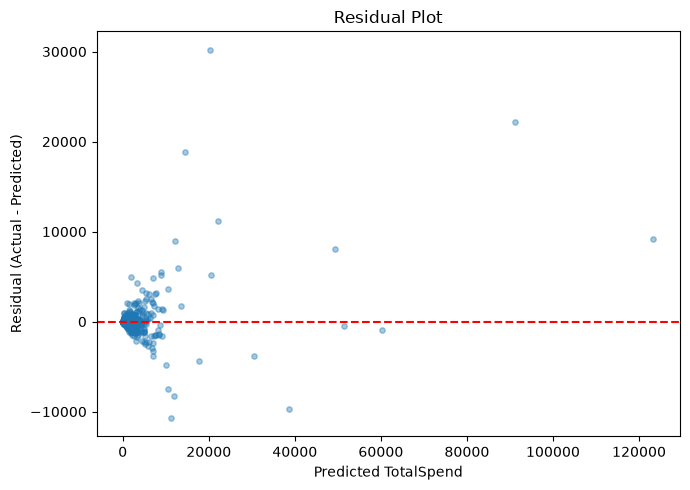

In [4]:
residuals = y_test.values - predictions

print("Mean residual:", round(residuals.mean(), 2))
print("Residual std:", round(residuals.std(), 2))

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(predictions, residuals, alpha=0.4, s=15)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted TotalSpend")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

## Least Squares

**What it is:** the method Linear Regression uses internally to find the
best-fitting line. It specifically minimizes the *sum of squared
residuals*, squaring each residual before summing them, so that large
errors are penalized much more heavily than small ones, and negative and
positive residuals don't cancel each other out.

## Cost Function

**What it is:** a formal name for the quantity being minimized during
training. For Linear Regression under least squares, the cost function is
the Mean Squared Error (MSE), the average of all squared residuals. The
"best" line is the one that produces the lowest possible MSE on the
training data.

In [5]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error (the cost function's value on test data):", round(mse, 2))
print("Root Mean Squared Error (same units as TotalSpend):", round(np.sqrt(mse), 2))
print("R-squared:", round(r2_score(y_test, predictions), 3))

Mean Squared Error (the cost function's value on test data): 3519288.91
Root Mean Squared Error (same units as TotalSpend): 1875.98
R-squared: 0.938


## Gradient Descent, Introduction

**What it is:** an iterative optimization algorithm that finds the
coefficients minimizing the cost function, by repeatedly adjusting them
in the direction that reduces error the fastest (the negative gradient),
taking small steps until it converges on the best values.

For simple problems like ours, scikit-learn's `LinearRegression` actually
uses a direct mathematical solution (the Normal Equation) rather than
gradient descent, it's fast enough for this size of problem. Gradient
descent becomes essential for much larger datasets or more complex
models (like neural networks) where the direct mathematical solution is
too expensive to compute.

## Multiple Linear Regression with Scikit-learn

Now using three independent variables together.

In [6]:
feature_cols = ["TotalQuantity", "NumOrders", "AvgUnitPrice"]
X_multi = customer_df[feature_cols]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

for feature, coef in zip(feature_cols, multi_model.coef_):
    print(f"Coefficient for {feature}: {coef:.3f}")
print("Intercept:", round(multi_model.intercept_, 3))

multi_predictions = multi_model.predict(X_test_m)
print("\nMultiple Regression R-squared:", round(r2_score(y_test_m, multi_predictions), 3))
print("Simple Regression R-squared (for comparison):", round(r2_score(y_test, predictions), 3))

Coefficient for TotalQuantity: 1.543
Coefficient for NumOrders: 65.673
Coefficient for AvgUnitPrice: 0.133
Intercept: -167.876

Multiple Regression R-squared: 0.936
Simple Regression R-squared (for comparison): 0.938


Adding `NumOrders` and `AvgUnitPrice` alongside `TotalQuantity` actually
produced a very slightly *lower* R-squared (0.936 vs 0.938) here, not an
improvement. This is a realistic and useful result: `TotalQuantity`
already carries almost all the predictive signal (matching its 0.92 raw
correlation with `TotalSpend`), and the extra variables add little beyond
noise for this particular target, splitting the model's attention across
inputs that don't meaningfully help. More features isn't automatically
better, exactly the same lesson from the Feature Selection notebooks in
the earlier series, now showing up directly in a regression context.

## Implementing Simple Linear Regression with NumPy (The Underlying Math)

Scikit-learn's `LinearRegression` solves for the coefficient and
intercept using the **Normal Equation**, a direct, closed-form solution
derived from calculus (setting the derivative of the cost function to
zero and solving). For simple linear regression with one variable, this
reduces to:

`m = sum((x - x_mean) * (y - y_mean)) / sum((x - x_mean)^2)`

`b = y_mean - m * x_mean`

Let's compute this by hand with NumPy and confirm it matches
scikit-learn's result exactly.

In [7]:
x = X_train["TotalQuantity"].values.astype(float)
y_vals = y_train.values.astype(float)

x_mean = np.mean(x)
y_mean = np.mean(y_vals)

# Least squares formula, computed manually
numerator = np.sum((x - x_mean) * (y_vals - y_mean))
denominator = np.sum((x - x_mean) ** 2)

m_manual = numerator / denominator
b_manual = y_mean - m_manual * x_mean

print("Manually computed slope (m):", round(m_manual, 3))
print("Manually computed intercept (b):", round(b_manual, 3))
print()
print("Scikit-learn's coefficient:", round(simple_model.coef_[0], 3))
print("Scikit-learn's intercept:", round(simple_model.intercept_, 3))
print()
print("Match confirmed:", np.isclose(m_manual, simple_model.coef_[0]) and np.isclose(b_manual, simple_model.intercept_))

Manually computed slope (m): 1.597
Manually computed intercept (b): 95.37

Scikit-learn's coefficient: 1.597
Scikit-learn's intercept: 95.37

Match confirmed: True


## Manually Predicting and Comparing Residuals

Using our hand-computed `m` and `b` to predict, and confirming the
predictions match scikit-learn's exactly.

In [8]:
x_test_vals = X_test["TotalQuantity"].values.astype(float)
manual_predictions = m_manual * x_test_vals + b_manual

print("Manual predictions (first 5):", manual_predictions[:5].round(2))
print("Scikit-learn predictions (first 5):", predictions[:5].round(2))
print("\nAll predictions match:", np.allclose(manual_predictions, predictions))

Manual predictions (first 5): [3129.88  620.82  671.93  392.43  893.93]
Scikit-learn predictions (first 5): [3129.88  620.82  671.93  392.43  893.93]

All predictions match: True
